# Random Forest

***🧠 Quick Concepts:***

1. **Random Forest** is a bagging method that combines multiple decision trees.
2. **Cross-validation (CV)** helps check if your model performs well across different data splits, reducing overfitting.
3. Like XGBoost, random forests are **ensembles of decision trees**.
4. The difference is that random forests **combine trees** via **bagging**, while XGBoost **combines trees** via **boosting**.
5. Random forest classifiers and Random forest regressors

# 1. Bagging ensembles

### 📘 Ensemble Methods in Machine Learning

#### 1. What is an Ensemble Method?

An **ensemble method** is a machine learning technique that **aggregates the predictions of multiple models** to produce a more accurate and robust final prediction. By leveraging the strengths of diverse models (or multiple versions of the same model), ensemble methods aim to improve generalization and reduce errors.

---

#### 2. Why Use Ensemble Methods?

Ensemble methods are typically **more reliable and accurate** than individual models because:

* They **reduce overfitting** by balancing out model biases.
* They **increase robustness** by smoothing out errors from weak learners.
* They often yield **higher performance**, particularly on real-world noisy datasets.

---

#### 3. How Do Ensemble Methods Work?

Let’s walk through an example:

**Goal:** Predict whether a house will sell within the first month.

You build three classifiers:

* **Logistic Regression** – 80% accuracy
* **Decision Tree** – 75% accuracy
* **K-Nearest Neighbors (KNN)** – 77% accuracy

Rather than choosing just the best model (logistic regression), you can use **majority voting**:

> If at least **two out of three** models predict “YES,” then the ensemble prediction is “YES”; otherwise, it’s “NO.”

This simple voting strategy is a type of **hard voting** and often leads to **improved overall performance** by aggregating model strengths.

---

#### 4. How Accurate Are Ensemble Methods?

Ensemble models generally achieve **higher accuracy** because:

* A wrong prediction occurs only when the **majority** of models are incorrect.
* **Individual weaknesses are averaged out**, enhancing overall stability and reducing the impact of outliers or noise.

---

#### 5. Types of Ensemble Methods

Ensemble methods are typically classified into two broad categories:

---

##### a. **Heterogeneous Ensembles (Different Models)**

These combine **various model types** (e.g., logistic regression, decision trees, SVMs) into a single prediction system.
Tool: **`VotingClassifier`** from scikit-learn

Example strategy:

* Combine outputs using **majority vote** (for classification) or **average** (for regression).

---

##### b. **Homogeneous Ensembles (Same Model, Repeated)**

These use **multiple instances of the same base model**, typically trained on different data samples or feature subsets.

Key methods:

* **Random Forest**

  * Uses **many decision trees** trained on **bootstrapped samples** (random subsets of data with replacement).
  * Combines outputs via:

    * **Majority vote** for classification.
    * **Average prediction** for regression.
  * Uses a special technique called **bagging** (*bootstrap aggregation*), which helps reduce variance and improves generalization by ensuring each tree is trained on a slightly different dataset.

* **XGBoost**

  * Trains decision trees **sequentially**, each focusing on correcting the errors of the previous.
  * Employs **boosting**, a technique that emphasizes misclassified examples to improve learning iteratively.

---

#### 4. How Accurate Are Ensemble Methods?

Ensemble methods typically offer **higher accuracy** because:

* A wrong prediction requires the **majority** of models to be wrong.
* **Individual model errors are averaged out**, making the ensemble less sensitive to noise and outliers.

---

#### 5. Types of Ensemble Methods

Ensemble techniques are broadly categorized into two types:

* **a. Heterogeneous Ensembles (Different Models)**
  Combines **different types of models** (e.g., logistic regression, decision trees, KNN) using methods like **`VotingClassifier`** in scikit-learn.

* **b. Homogeneous Ensembles (Same Model, Multiple Times)**
  Combines **multiple versions of the same base model**, typically trained on different subsets or feature sets. Examples include:

  * **Random Forest** – Many decision trees trained with bootstrapped samples and random feature subsets.
  * **XGBoost** – Sequentially builds multiple decision trees, improving predictions iteratively.

# 2. Bootstrap aggregation

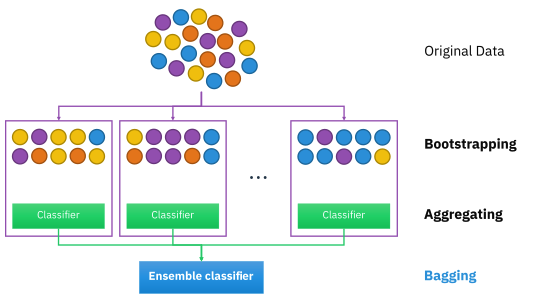

## 2.1 Bootstrapping phase

**1. What's bootstrapping?**

**Bootstrapping** means sampling with **replacement**.

---

**2. Why Is "With Replacement" Crucial in Bagging**

As shown in the diagram:

* The **original data** contains 20 colored marbles (data points).
* During **bootstrapping**, each new sample (for training a classifier) is created by randomly drawing marbles **with replacement**.
* These bootstrap samples are then used to train individual **classifiers**, whose predictions are **aggregated** to form an **ensemble classifier** — this is called **bagging**.

---

**❓ What Happens If We Don't Use Replacement?**

If sampling was done **without replacement**:

* Each bootstrap sample would be a **reshuffling** of the original 20 marbles — no duplicates.
* Every sample would contain **exactly the same class distribution** as the original data (just in different order).
* It would be **impossible** for a sample to over-represent any class (e.g., more blue marbles than originally exist).

But in **with replacement**, as seen in the three boxes:

* Some marbles (colors) **repeat**, and others may be **missing entirely**.
* For example, the third sample has **lots of purple and blue marbles**, possibly more than in the original 20 — this can happen only through **repeated sampling with replacement**.

---

**🔁 Why It Matters for Ensemble Learning**

This variability introduced by **sampling with replacement**:

* Creates **diverse classifiers**, since each one sees a slightly different version of the data.
* Helps reduce **variance**, which is the key idea behind bagging.

If you didn’t use replacement, all models would learn from the **same data**, reducing the benefit of having multiple classifiers.

---

**✅ Final Explanation**

1. In bagging, **bootstrap samples are created by sampling with replacement** from the original dataset. If replacement were not allowed, each sample would be identical in class distribution to the original data. As a result, it would be **impossible** to create a sample that, for instance, has **more blue marbles than the original set**. This diversity — such as the overrepresentation of blue marbles in one classifier's training set — is what gives bagging its strength.

2. In **random forests**, each decision tree is trained on a **bootstrap sample**—a random sample **with replacement** from the original data. This ensures that:

* **Each tree sees a slightly different subset** of the data.
* On average, about **two-thirds of the samples are unique**, and **one-third are duplicates**.

This diversity helps prevent all trees from making similar predictions, improving the overall performance of the ensemble.



## 2.2 Aggregation Phase

After **bootstrapping**, each decision tree in a **random forest** makes its **own prediction**.

* For **classification**, the final prediction is based on the **majority vote** across all trees.
* For **regression**, the final output is the **average** of all tree predictions.

This aggregation improves overall accuracy and stability compared to using a single decision tree.


# 3. How Random Forests Work

## 3.1 Random forest classifiers

In this demo we use a **RandomForestClassifier** to predict whether a user makes more or less than USD 50,000 using the **CLEANED** census dataset

In [1]:
# Import pandas
import pandas as pd

# Import numpy
import numpy as np

# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Import cross_val_score
from sklearn.model_selection import cross_val_score

# Silence warnings
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Upload csv file 'census_cleaned' as df_census
df_census = pd.read_csv('census_cleaned.csv')

df_census.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income_ >50K
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,38,215646,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,53,234721,7,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,28,338409,13,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df_census.columns

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_ ?', 'workclass_ Federal-gov',
       'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private',
       'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc',
       'workclass_ State-gov', 'workclass_ Without-pay',
       'marital-status_ Divorced', 'marital-status_ Married-AF-spouse',
       'marital-status_ Married-civ-spouse',
       'marital-status_ Married-spouse-absent',
       'marital-status_ Never-married', 'marital-status_ Separated',
       'marital-status_ Widowed', 'occupation_ ?', 'occupation_ Adm-clerical',
       'occupation_ Armed-Forces', 'occupation_ Craft-repair',
       'occupation_ Exec-managerial', 'occupation_ Farming-fishing',
       'occupation_ Handlers-cleaners', 'occupation_ Machine-op-inspct',
       'occupation_ Other-service', 'occupation_ Priv-house-serv',
       'occupation_ Prof-specialty', 'occupation_ Protective-serv',
     

In [ ]:
# Split data into X and y
X_census = df_census.iloc[:,:-1]
y_census = df_census.iloc[:,-1]

In [4]:
print(f"X_census.shape: {X_census.shape}")
print(f"y_census.shape: {y_census.shape}")

X_census.shape: (32561, 92)
y_census.shape: (32561,)


In [6]:
X_census.columns

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_ ?', 'workclass_ Federal-gov',
       'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private',
       'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc',
       'workclass_ State-gov', 'workclass_ Without-pay',
       'marital-status_ Divorced', 'marital-status_ Married-AF-spouse',
       'marital-status_ Married-civ-spouse',
       'marital-status_ Married-spouse-absent',
       'marital-status_ Never-married', 'marital-status_ Separated',
       'marital-status_ Widowed', 'occupation_ ?', 'occupation_ Adm-clerical',
       'occupation_ Armed-Forces', 'occupation_ Craft-repair',
       'occupation_ Exec-managerial', 'occupation_ Farming-fishing',
       'occupation_ Handlers-cleaners', 'occupation_ Machine-op-inspct',
       'occupation_ Other-service', 'occupation_ Priv-house-serv',
       'occupation_ Prof-specialty', 'occupation_ Protective-serv',
     

In [5]:
X_census.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,77516,13,2174,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,0,0,13,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,0,0,40,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Step 1: Initialize the Random Forest classifier
# - n_estimators=10 means it will build 10 decision trees
# - random_state=2 ensures reproducible results
# - n_jobs=-1 lets it use all CPU cores for faster training
rf = RandomForestClassifier(n_estimators=10, random_state=2, n_jobs=-1)

# Step 2: Evaluate model using 5-fold cross-validation
# - This splits the data into 5 parts, trains on 4, tests on 1 (rotated 5 times)
# - Returns an array of accuracy scores (one for each fold)
scores = cross_val_score(rf, X_census, y_census, cv=5)

# Step 3: Print the accuracy scores for each fold
# - np.round(..., 3) rounds each score to 3 decimal places for cleaner display
print('Accuracy:', np.round(scores, 3))

# Step 4: Print the average (mean) accuracy across all 5 folds
print('Accuracy mean: %0.3f' % (scores.mean()))

Accuracy: [0.851 0.844 0.851 0.852 0.851]
Accuracy mean: 0.850


---

### 📊 Model Performance on the Census Dataset

| Model                                  | Accuracy (%) |
| -------------------------------------- | ------------ |
| Decision Tree                          | 81%          |
| **Random Forest** *(default settings)* | **83–84%**   |
| XGBoost                                | **86%**      |

📝 **Insight**:
The default **Random Forest Classifier** performs **better than a single Decision Tree**, thanks to its ensemble nature. However, it **doesn't quite match the performance of XGBoost**, which is a boosting-based method that often achieves higher accuracy by correcting errors in sequence.

---

---

### ❓ Why does Random Forest perform better than individual decision trees?

**✅ Answer:**
Random Forest improves performance through the **bagging** technique:

* It builds **multiple decision trees** (e.g., 10 trees when `n_estimators=10`).
* Each tree is trained on a **bootstrapped sample** (random subset with replacement), increasing **diversity** among trees.
* The final prediction is made by **aggregating** all tree outputs (majority vote for classification), which reduces **variance**.
* This leads to **more stable and accurate** predictions compared to a single decision tree.

---


---

### ❓ How do Random Forests reduce variance through feature selection?

**✅ Answer:**
By default, each tree in a Random Forest considers only a **subset of features** when splitting nodes:

* Specifically, it selects from **√(total number of features)** — for example, only 10 out of 100 features.
* This means that even if **two trees see the same data**, they may choose **different splits** due to different feature subsets.
* This introduces **diversity among trees**, leading to less correlation between them and thus a **lower overall variance** in the final ensemble prediction.

---

---

### ❓ Is the feature subset in Random Forests selected randomly or based on a formula?

**✅ Answer:**
Both!

* **Random selection**:
  Yes, at **each split**, Random Forests **randomly select a subset of features** to consider for that split (not the same subset every time).

* **Mathematical rule for subset size**:
  The **number of features** to randomly select is based on a **default heuristic**:

  * **For classification** tasks: use √(total number of features)
  * **For regression** tasks: use (total number of features) ÷ 3
    *(These are defaults in scikit-learn, and you can override them with `max_features`)*

📌 Example:
If there are 100 total features:

* In classification → consider **√100 = 10** random features at each split
* In regression → consider **100 ÷ 3 ≈ 33** random features at each split

So while the subset is chosen **randomly**, the **size** of the subset follows a **mathematical rule**.

---

## 3.2 Random forest regressors

In a random forest regressor, the samples are bootstrapped, as with the random forest Classifier, but the max number of features is the total number of features instead of the square root.

---

***❓ How does feature selection differ between RandomForestClassifier and RandomForestRegressor?***

**✅ Answer:**
Both models use the **Random Forest** algorithm, which builds an ensemble of decision trees trained on **bootstrapped samples** (random samples with replacement).
However, they differ in two key ways:

---

#### 🔁 Feature Selection at Each Split:

* **RandomForestClassifier**:
  At each split in each tree, a **random subset** of features is considered.
  By default, this subset is of size **√(total number of features)**.
  This promotes **diversity** among trees and helps reduce overfitting in classification tasks.

* **RandomForestRegressor**:
  At each split, the model typically considers **all available features** by default.
  This allows trees to use **more information** when modeling continuous numeric outcomes.

---

#### 📊 Aggregating Predictions:

* **Classifier**:
  The final prediction is based on a **majority vote** across all decision trees.

* **Regressor**:
  The final prediction is computed by taking the **average of all tree predictions**, which is more appropriate for continuous numeric values.

---

📌 You can override the default feature selection behavior using the `max_features` parameter in both models.

---

In [12]:
# Upload csv file 'bike_rentals_cleaned' as df_bikes
df_bikes = pd.read_csv('bike_rentals_cleaned.csv')

df_bikes.shape

(731, 13)

In [14]:
df_bikes.columns

Index(['instant', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

In [13]:
# Show first 5 rows
df_bikes.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1.0,0.0,1.0,0.0,6.0,0.0,2,0.344167,0.363625,0.805833,0.160446,985
1,2,1.0,0.0,1.0,0.0,0.0,0.0,2,0.363478,0.353739,0.696087,0.248539,801
2,3,1.0,0.0,1.0,0.0,1.0,1.0,1,0.196364,0.189405,0.437273,0.248309,1349
3,4,1.0,0.0,1.0,0.0,2.0,1.0,1,0.200000,0.212122,0.590435,0.160296,1562
4,5,1.0,0.0,1.0,0.0,3.0,1.0,1,0.226957,0.229270,0.436957,0.186900,1600


In [15]:
# Split data into X and y
X_bikes = df_bikes.iloc[:,:-1]
y_bikes = df_bikes.iloc[:,-1]

In [16]:
print(f"X_bikes.shape: {X_bikes.shape}")
print(f"y_bikes.shape: {y_bikes.shape}")

X_bikes.shape: (731, 12)
y_bikes.shape: (731,)


In [17]:
# Step 1: Import the Random Forest Regressor model
from sklearn.ensemble import RandomForestRegressor

# Step 2: Create a RandomForestRegressor object
# - n_estimators=10: builds 10 decision trees
# - random_state=2: ensures reproducible results
# - n_jobs=-1: uses all available CPU cores for faster computation
rf = RandomForestRegressor(n_estimators=10, random_state=2, n_jobs=-1)

# Step 3: Evaluate the model using 10-fold cross-validation
# - scoring='neg_mean_squared_error': we use negative MSE (sklearn convention)
# - cv=10: splits the data into 10 parts for cross-validation
# - This returns 10 negative MSE scores (one from each fold)
scores = cross_val_score(rf, X_bikes, y_bikes, scoring='neg_mean_squared_error', cv=10)

# Step 4: Convert negative MSE to positive and take the square root to get RMSE
# - RMSE (Root Mean Squared Error) is easier to interpret in the original target units
rmse = np.sqrt(-scores)

# Step 5: Print the RMSE scores from each fold, rounded to 3 decimal places
print('RMSE:', np.round(rmse, 3))

# Step 6: Print the average RMSE across all 10 folds
# - Lower RMSE means better performance (closer to actual values)
print('RMSE mean: %0.3f' % (rmse.mean()))

# RMSE: [ 801.486  579.987  551.347  846.698  895.05  1097.522  893.738  809.284
#   833.488 2145.046]
# RMSE mean: 945.365

RMSE: [ 801.486  579.987  551.347  846.698  895.05  1097.522  893.738  809.284
  833.488 2145.046]
RMSE mean: 945.365


---

### 🧠 Key Concepts Recap:

* **Random Forest Regressor**:
  An ensemble model that builds multiple decision trees and averages their predictions for more accurate results on regression tasks.

* **Cross-validation (CV)**:
  A technique that splits the dataset into multiple folds, trains the model on some, and tests on the remaining. This helps get a more reliable estimate of model performance.

* **MSE (Mean Squared Error)**:
  A common regression error metric that calculates the **average of squared differences** between the predicted and actual values. Lower MSE means better performance.

* **RMSE (Root Mean Squared Error)**:
  The square root of MSE — this puts the error back into the **original units** of the target variable, making it easier to interpret.

* **Why `neg_mean_squared_error` instead of `mean_squared_error` in `cross_val_score`?**
  `cross_val_score()` is designed to treat **higher scores as better**, like accuracy.
  But MSE is a **loss function** (lower is better), so scikit-learn **returns the negative of the MSE** to keep the convention consistent.
  That’s why you see:

  ```python
  scores = cross_val_score(..., scoring='neg_mean_squared_error')
  ```

  And later:

  ```python
  rmse = np.sqrt(-scores)  # Flip sign back and take square root
  ```

  ✅ **Bottom line**:
  Using `'neg_mean_squared_error'` ensures compatibility with `cross_val_score()`'s design, while still letting you compute RMSE properly.

---

# 4. Random Forest Hyperparameters

## 4.1 oob_score

---

***🧠 Quick Note on `oob_score=True`***:

* **OOB score** is like a built-in cross-validation:

  * Since each tree is trained on a **bootstrapped subset**, some samples are **left out**.
  * These “left-out” samples are used to **evaluate** the model without needing a separate validation set.
  * After fitting, you can access the score using:

    ```python
    print("OOB Score:", rf.oob_score_)
    ```

---

In [19]:
# Step 1: Import the RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Step 2: Initialize the Random Forest Classifier
# - oob_score=True: enables out-of-bag (OOB) score calculation for model evaluation
#   (OOB samples are those not included in the bootstrap sample for a given tree)
# - n_estimators=10: builds 10 decision trees in the forest
# - random_state=2: sets a seed for reproducibility of results
# - n_jobs=-1: uses all available CPU cores for faster computation
rf = RandomForestClassifier(oob_score=True, n_estimators=10, random_state=2, n_jobs=-1)

# Step 3: Train (fit) the Random Forest model using the Census dataset
# - X_census: the feature matrix (input data)
# - y_census: the target labels (e.g., income >50K or not)
rf.fit(X_census, y_census)

RandomForestClassifier(n_estimators=10, n_jobs=-1, oob_score=True,
                       random_state=2)

In [20]:
# Display oob score
rf.oob_score_

0.8343109855348423

---

### ❓ What does `rf.oob_score_` tell us in a Random Forest?

**✅ Answer:**
`rf.oob_score_` gives you an estimate of your model’s **accuracy** (or R² score in regression) using **out-of-bag (OOB) samples** — i.e., the data points **not used** when training each individual decision tree.

---

### 🔍 What are Out-of-Bag (OOB) Samples?

* When training a Random Forest, each tree is trained on a **random bootstrap sample** — a subset drawn **with replacement** from the training data.
* As a result, about **1/3 of the data is *not used*** in training that particular tree — these are called **OOB samples**.
* Since those samples weren’t seen by the tree, they can be used to **test that tree**, giving an **unbiased estimate** of performance.

---

### 📊 What does the value of `rf.oob_score_` mean?

* For classification: it’s the **accuracy score** on the OOB samples
  *(e.g., `rf.oob_score_ = 0.84` means \~84% accuracy on unseen training data)*
* For regression: it's the **R² score** (coefficient of determination)

---

### ✅ Why is this useful?

* It provides a **built-in validation method**, so you don’t need a separate test set (especially helpful for small datasets).
* It's faster and more efficient than cross-validation, though slightly less robust.

---

### 💡 Example:

```python
rf = RandomForestClassifier(oob_score=True, n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("OOB Score:", rf.oob_score_)
```

**Output:**

```
OOB Score: 0.842
```

🧠 This means: the model correctly classified about 84.2% of the out-of-bag training samples.

---

---

### 📊 Comparing `oob_score_` vs. Cross-Validation Accuracy in Random Forests

When training a `RandomForestClassifier` (or `Regressor`), you can evaluate model performance using:

* ✅ **Out-of-Bag Score (`oob_score_`)**
* ✅ **Cross-Validation Score (`cross_val_score`)**

Let’s compare these two:

---

### 🔁 1. **Out-of-Bag Score (`rf.oob_score_`)**

* Built-in to Random Forests when `oob_score=True`
* Uses about **1/3 of training data** (the OOB samples) as a **validation set** for each tree
* **Efficient** and fast: no need to manually split data
* Less variance than single holdout set, but **may be slightly optimistic**
* 🧪 Access via:

  ```python
  rf.oob_score_
  ```

---

### 🔂 2. **Cross-Validation (`cross_val_score`)**

* Splits training data into **k folds** (e.g., 5 or 10)
* Trains on k−1 folds and tests on the remaining fold (rotated)
* **More robust** estimate of model generalization
* Slower than OOB but useful across **any model**, not just Random Forests
* 🧪 Example:

  ```python
  from sklearn.model_selection import cross_val_score
  scores = cross_val_score(rf, X_train, y_train, cv=5)
  print("CV Accuracy Mean:", scores.mean())
  ```

---

### ✅ Summary Table

| Aspect              | `oob_score_`               | `cross_val_score`       |
| ------------------- | -------------------------- | ----------------------- |
| Model compatibility | Only Random Forest         | Any model               |
| Speed               | Fast                       | Slower                  |
| Reusability         | Automatic during `.fit()`  | Manual                  |
| Accuracy estimate   | Slightly optimistic        | More stable and robust  |
| Data efficiency     | High (no need to hold out) | Depends on `cv` setting |

---

### 💡 Tip:

* Use `oob_score_` for quick internal validation during experimentation.
* Use `cross_val_score` for **formal evaluation**, model comparison, or **hyperparameter tuning**.

---

---

***🌲 Summary: Impact of `n_estimators` on `oob_score_` in Random Forests***

* **Random Forest performance improves** as you increase the number of trees (`n_estimators`), especially at lower values.
* Adding more trees helps reduce **variance** and improve **out-of-bag (OOB) score** — a built-in validation estimate.

---

### 🔢 Example Comparison (on Census Data):

| `n_estimators` | `oob_score_` | Change  |
| -------------- | ------------ | ------- |
| 50             | 0.8519       | —       |
| 100            | 0.8551       | +0.0032 |

---

### 📈 Key Insight:

* Increasing from **50 to 100 trees** gives a **small boost** in OOB score.
* **Diminishing returns**: Beyond a point, adding more trees yields **smaller gains** in performance.
* For large datasets, **500+ trees** may help slightly — but at the cost of **longer training time**.

---

### ✅ Rule of Thumb:

* Start with `n_estimators=100`
* Use OOB score or cross-validation to check performance
* Increase gradually only if needed — especially for **larger or noisier datasets**

---


***oob_score when n_estimators=50***

In [ ]:
# Intialize Random Forest Classifier with n_estimators=50 and oob_score=True
rf = RandomForestClassifier(n_estimators=50, oob_score=True, random_state=2, n_jobs=-1)

# Fit Random Forest on Census Dataset
rf.fit(X_census, y_census)

# Display oob_score
rf.oob_score_

0.8518780135745216

***oob_score when n_estimators=100***

In [ ]:
# Intialize Random Forest Classifier with n_estimators=100 and oob_score=True
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=2, n_jobs=-1)

# Fit Random Forest on Census Dataset
rf.fit(X_census, y_census)

# Display oob_score
rf.oob_score_

0.8551334418476091

The gain is smaller. As n_estimators continues to rise, scores will eventually level off.

## 4.2 warm_start

The warm_start hyperparameter is great for determining the number of trees in the forest (n_estimators). When warm_start=True, adding more trees does not require starting over from scratch. If you change n_estimators from 100 to 200, it may take twice as long to build the forest with 200 trees. When warm_start=True, the random forest with 200 trees does not start from scratch, but rather starts where the previous model stopped.

warm_start may be used to plot various scores with a range of n_estimators.

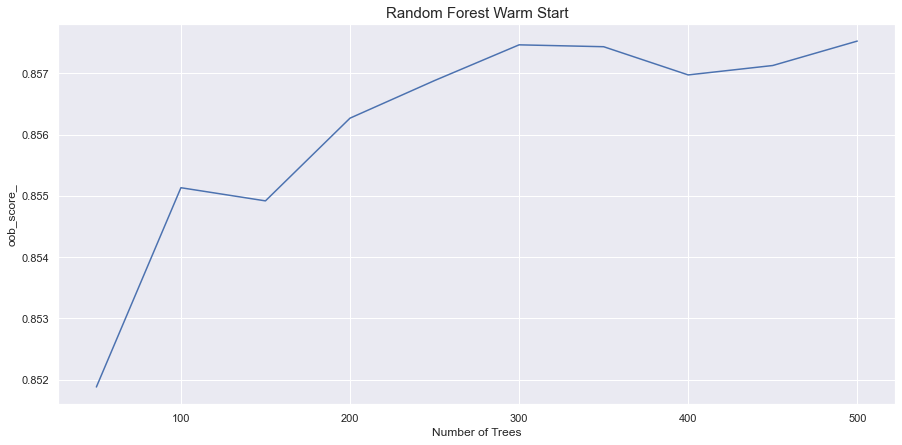

In [ ]:
# Step 1: Import plotting libraries
import matplotlib.pyplot as plt       # For plotting graphs
import seaborn as sns                 # For nicer-looking visualizations

# Step 2: Set a clean dark grid background for the plots (helps with readability)
sns.set()

# Step 3: Initialize an empty list to store out-of-bag scores as we grow the forest
oob_scores = []

# Step 4: Initialize a Random Forest Classifier
# - n_estimators=50: start with 50 trees
# - warm_start=True: allows us to add more trees later *without resetting* the model
# - oob_score=True: enables tracking of out-of-bag accuracy after each fit
# - n_jobs=-1: use all CPU cores
# - random_state=2: ensures reproducible results
rf = RandomForestClassifier(n_estimators=50, warm_start=True, oob_score=True, n_jobs=-1, random_state=2)

# Step 5: Fit the model to the Census dataset
# This will train the first 50 trees
rf.fit(X_census, y_census)

# Step 6: Save the current OOB score to our list
oob_scores.append(rf.oob_score_)

# Step 7: Start tracking how many estimators (trees) we’ve used so far
est = 50
estimators = [est]  # Also store the tree counts for plotting

# Step 8: Use a loop to add more trees to the model gradually
# - We’ll grow the forest by adding 50 trees each time, 9 more times (up to 500 trees)
for i in range(9):

    # Increase the tree count by 50
    est += 50

    # Track the number of trees for plotting
    estimators.append(est)

    # Update the Random Forest with the new number of trees
    rf.set_params(n_estimators=est)

    # Re-fit the model: this adds new trees without resetting the old ones (because warm_start=True)
    rf.fit(X_census, y_census)

    # Record the new OOB score
    oob_scores.append(rf.oob_score_)

# Step 9: Plot the number of trees vs. OOB score to visualize improvement
plt.figure(figsize=(15, 7))  # Set the figure size

# Plot how the out-of-bag score improves as more trees are added
plt.plot(estimators, oob_scores)

# Add axis labels and title
plt.xlabel('Number of Trees')          # X-axis: number of trees
plt.ylabel('oob_score_')               # Y-axis: OOB validation accuracy
plt.title('Random Forest Warm Start', fontsize=15)  # Title for the chart

# Optional: save the plot to a file (e.g., for documentation)
plt.savefig('Random_Forest_Warm_Start', dpi=325)

# Show the final plot
plt.show()

As you can see, the number of trees tends to peak at around 300. It's more costly and time-consuming to use more trees than 300, and the gains are minimal at best.

---

### 🧠 Why Use `warm_start=True`?

* Normally, changing `n_estimators` resets the model.
* With `warm_start=True`, we can **incrementally add more trees** without retraining from scratch.
* This allows us to **track performance** (e.g., OOB score) as we add trees — very useful for understanding how many trees are “enough.”

---

## 4.3 bootstrap

Although random forests are traditionally bootstrapped, the bootstrap hyperparameter may be set to False. If bootstrap=False, oob_score cannot be included since oob_score is only possible when samples have been left out.

We will not pursue this option, although it makes sense if underfitting occurs.

## 4.4 Verbose

The verbose hyperparameter may be changed to a higher number to display more information when building a model. You may try it on your own for experimentation. When building large models, verbose=1 may provide helpful information along the way.

---

## 🌲 Random Forest Hyperparameters

**Ref:** https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

### 🔧 **Model Complexity & Tree Control**

| Hyperparameter      | Description                                        | Default (Classifier)  | Effect                                                   |
| ------------------- | -------------------------------------------------- | --------------------- | -------------------------------------------------------- |
| `n_estimators`      | Number of trees in the forest                      | `100`                 | More trees = better performance (to a point), but slower |
| `max_depth`         | Maximum depth of each tree                         | `None` (expand fully) | Limits tree size → helps prevent overfitting             |
| `min_samples_split` | Minimum number of samples required to split a node | `2`                   | Larger value = less complex trees                        |
| `min_samples_leaf`  | Minimum samples at a leaf node                     | `1`                   | Larger values smooth the model, help reduce overfitting  |
| `max_leaf_nodes`    | Maximum number of leaf nodes                       | `None`                | Limits growth of tree structure                          |

---

### 🌿 **Feature Subsampling (Per Split)**

| Hyperparameter                 | Description                                  | Default                                                                 | Effect                                             |
| ------------------------------ | -------------------------------------------- | ----------------------------------------------------------------------- | -------------------------------------------------- |
| `max_features`                 | Number of features to consider at each split | `sqrt(n_features)` (for classification) / `n_features` (for regression) | Controls randomness → smaller = more diverse trees |
| `max_samples` *(new in v0.22)* | Number of samples drawn to train each tree   | `None` (use full bootstrap sample)                                      | Can sub-sample rows for additional randomness      |

---

### 🔁 **Bootstrap & Randomness**

| Hyperparameter | Description                         | Default | Effect                                             |
| -------------- | ----------------------------------- | ------- | -------------------------------------------------- |
| `bootstrap`    | Whether to use bootstrapped samples | `True`  | Set to `False` for full dataset per tree (rare)    |
| `random_state` | Seed for reproducibility            | `None`  | Use fixed value (e.g. `42`) for consistent results |

---

### ⚡ **Performance & Speed**

| Hyperparameter | Description                | Default         | Effect                                             |
| -------------- | -------------------------- | --------------- | -------------------------------------------------- |
| `n_jobs`       | Number of CPU cores to use | `None` (1 core) | `-1` uses all available cores → speeds up training |
| `verbose`      | Controls training logs     | `0`             | Set to `1` or `2` to see training progress         |

---

## 🧠 Practical Tips

* ✅ Start with a **baseline** model and then tune:

  * `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`
* ✅ Use **GridSearchCV** or **RandomizedSearchCV** for automated tuning
* ✅ For large datasets, set `n_jobs=-1` and limit `max_depth` to speed things up
* ✅ Don’t just increase `n_estimators` — after a point, performance gains are minimal

---